# 02 — Model Training

Trains a Random Forest classifier to predict whether a driver is **high-risk** based on telematics and claims features.

**Label definition**

```
high_risk = 1  if  num_claims >= 2
                or (num_claims == 1 AND responsible AND total_loss)
high_risk = 0  otherwise
```

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

sns.set_theme(style="whitegrid", palette="muted")
RANDOM_STATE = 42

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("../data/features.csv")
print(f"Loaded: {df.shape[0]} drivers × {df.shape[1]} cols")
df.head()

Loaded: 50 drivers × 9 cols


,customer_id,avg_speed,max_speed,harsh_braking_count,recklessness_score,trips_recorded,num_claims,responsible,total_loss
0,DRV_001,75.72,137.43,0,14.68,10,2,True,True
1,DRV_002,64.08,137.32,0,15.26,10,2,True,False
2,DRV_003,70.86,137.40,0,14.99,10,1,True,True
3,DRV_004,64.42,137.31,0,15.51,10,2,True,False
4,DRV_005,66.14,137.31,0,14.81,10,2,True,False


## 1. Label Engineering

high_risk
Low Risk (0)     33
High Risk (1)    17

High-risk rate: 34.0%


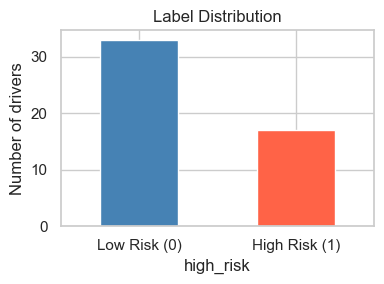

In [3]:
df["high_risk"] = (
    (df["num_claims"] >= 2)
    | ((df["num_claims"] == 1) & df["responsible"] & df["total_loss"])
).astype(int)

counts = df["high_risk"].value_counts().rename({0: "Low Risk (0)", 1: "High Risk (1)"})
print(counts.to_string())
print(f"\nHigh-risk rate: {df['high_risk'].mean():.1%}")

fig, ax = plt.subplots(figsize=(4, 3))
counts.plot(kind="bar", ax=ax, color=["steelblue", "tomato"], edgecolor="white", rot=0)
ax.set_ylabel("Number of drivers")
ax.set_title("Label Distribution")
plt.tight_layout()
plt.show()

## 2. Train / Test Split

Features: `avg_speed`, `max_speed`, `harsh_braking_count`, `recklessness_score`, `trips_recorded`, `num_claims`  
Stratified split preserves the 32 % high-risk ratio in both train and test sets.

In [4]:
FEATURE_COLS = [
    "avg_speed",
    "max_speed",
    "harsh_braking_count",
    "recklessness_score",
    "trips_recorded",
    "num_claims",
]

X = df[FEATURE_COLS]
y = df["high_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train : {len(X_train)} samples  |  high_risk = {y_train.sum()} ({y_train.mean():.0%})")
print(f"Test  : {len(X_test)} samples   |  high_risk = {y_test.sum()} ({y_test.mean():.0%})")

Train : 40 samples  |  high_risk = 14 (35%)
Test  : 10 samples   |  high_risk = 3 (30%)


## 3. Train Random Forest

In [5]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight="balanced",
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(f"Train accuracy: {rf.score(X_train, y_train):.3f}")
print(f"Test  accuracy: {rf.score(X_test,  y_test):.3f}")

Train accuracy: 1.000
Test  accuracy: 1.000


## 4. Evaluation

### 4a. Confusion Matrix

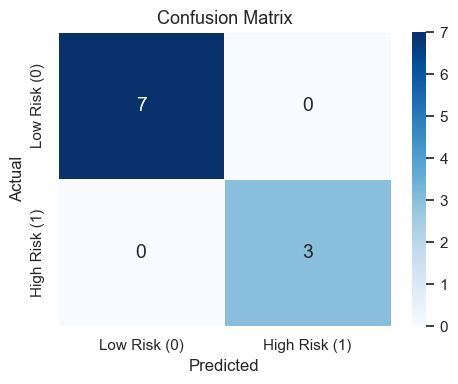

In [6]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    xticklabels=["Low Risk (0)", "High Risk (1)"],
    yticklabels=["Low Risk (0)", "High Risk (1)"],
    annot_kws={"size": 14},
    ax=ax,
)
ax.set_ylabel("Actual", fontsize=12)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_title("Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.show()

### 4b. Classification Report

In [7]:
print(classification_report(y_test, y_pred, target_names=["Low Risk", "High Risk"]))

              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00         7
   High Risk       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



### 4c. Feature Importance

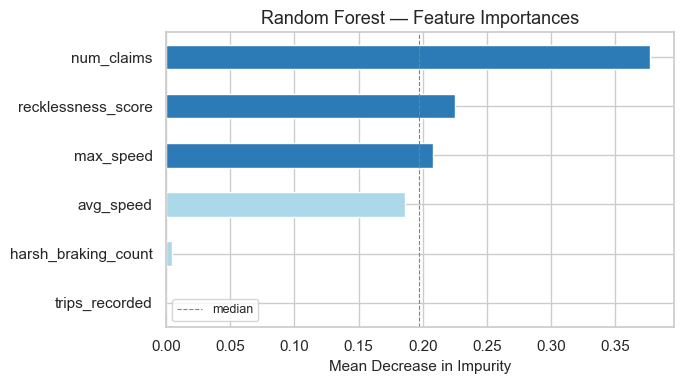


Ranked importances:
num_claims             0.376751
recklessness_score     0.224784
max_speed              0.207692
avg_speed              0.185990
harsh_braking_count    0.004783
trips_recorded         0.000000


In [8]:
importances = (
    pd.Series(rf.feature_importances_, index=FEATURE_COLS)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#2c7bb6" if v >= importances.median() else "#abd9e9" for v in importances]
importances.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_xlabel("Mean Decrease in Impurity", fontsize=11)
ax.set_title("Random Forest — Feature Importances", fontsize=13)
ax.axvline(importances.median(), color="grey", linestyle="--", linewidth=0.8, label="median")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nRanked importances:")
print(importances.sort_values(ascending=False).to_string())

## 5. Save Model

In [9]:
os.makedirs("../models", exist_ok=True)
model_path = "../models/risk_model.pkl"

joblib.dump({"model": rf, "feature_cols": FEATURE_COLS}, model_path)
print(f"Saved → {model_path}")

# Quick reload sanity check
payload = joblib.load(model_path)
assert list(payload["feature_cols"]) == FEATURE_COLS
assert payload["model"].score(X_test, y_test) == rf.score(X_test, y_test)
print("Reload check passed.")

Saved → ../models/risk_model.pkl
Reload check passed.
